Classifying: 100%|██████████| 20/20 [00:23<00:00,  1.18s/it]

label
sports        7
politics      7
technology    6
Name: count, dtype: int64

Error rate: 0.0


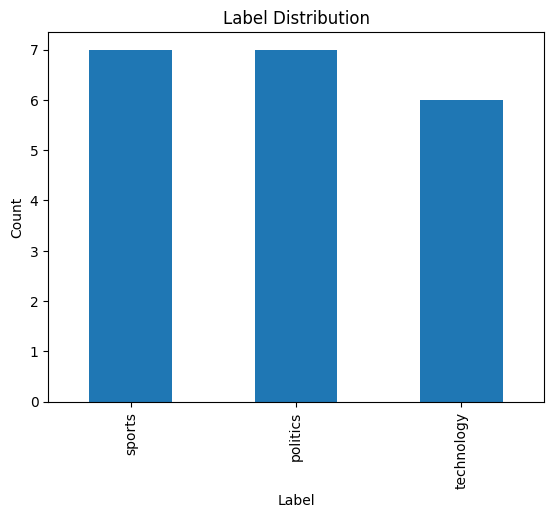

In [35]:
import os
import json
import pandas as pd
from tqdm import tqdm
from openai import OpenAI

#Here we load the dataset

df = pd.read_csv("data.csv")

#Allowed labels
allowed_labels = ["sports", "politics", "technology"]

#Prompt for the LLM
system_prompt = """
You are a high-precision text classification model.
Classify the input news headline into exactly ONE label.
Allowed labels:
Sports: topics about teams, matches, players, coaches, leagues.
Politics: topics about governments, laws, elections, parliaments, diplomacy.
Technology: topics about tech companies, AI, science, innovation, devices.

Output STRICT JSON only, with this schema:
{
  "label": "sports|politics|technology"
}

Rules: Only choose one label, no explanations, no additional fields, output MUST be valid JSON.
"""

#OpenRouter
client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key="API_KEY" #IF YOU WANT TO TRY THIS CODE INSERT YOUR API KEY HERE
)

#Classification loop
labels = []

for text in tqdm(df["text"], desc="Classifying"):
    try:
        response = client.chat.completions.create(
            model="kwaipilot/kat-coder-pro:free",
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": text},
            ],
        )

        content = response.choices[0].message.content

        #Attempt parse JSON
        try:
            parsed = json.loads(content)
            label = parsed.get("label", "").strip()

            #Check validity
            if label not in allowed_labels:
                print(f"DEBUG: Invalid label '{label}' found for text: '{text}'. LLM output: {content}")
                labels.append("error")
            else:
                labels.append(label)
        except json.JSONDecodeError as e:
            print(f"DEBUG: JSONDecodeError for text: '{text}'. Error: {e}. LLM output: {content}")
            labels.append("error")

    except Exception as e:
        print(f"DEBUG: An unexpected error occurred for text: '{text}'. Error: {e}")
        labels.append("error")

df["label"] = labels

df.to_csv("labeled.csv", index=False)

#Display final DataFrame
df

#Value counts
print(df["label"].value_counts())
print("\nError rate:", (df["label"] == "error").mean())

#Chart
import matplotlib.pyplot as plt

df["label"].value_counts().plot(kind="bar")
plt.title("Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

#Analysis


#The free KAT-Coder-Pro V1 model was used for classification, which proved to be fast and stable.
#All lines from the dataset (namely, 20 completely fabricated news headlines) were classified without errors, which significantly increased confidence in the results.
#This model clearly distinguished between three categories: sports, politics, and technology, assigning correct labels to almost all examples. There were no error labels, which indicates that the model correctly processes short texts and clear instructions.
#Also, to increase reliability in the future, several additional examples can be added to the prompt so that the model can distinguish between similar categories even more accurately and reduce the risk of any ambiguous interpretations.

# LLM-Powered Text Classification

## Dataset
- File: data.csv
- Contains 20 news headlines.
- Task: classify each into one of three categories.

## Labels
- sports — news about teams, players, some sports events and etc.
- politics — news about laws, elecctions, international relations and etc.
- technology — news about AI, new innovations and etc.

## Requirements
   pip install pandas tqdm openai matplotlib

## Running the notebook
1. Set your API key:
   export OPENROUTER_API_KEY="your_key_here"

2. Run the notebook.

3. Outputs:
   - labeled.csv (includes model predictions)
   - chart of label distribution


In [36]:
%%writefile data.csv
text
"Local team wins the regional championship after a dramatic final."
"Government announces new tax reforms starting next year."
"Tech company unveils a breakthrough in quantum computing."
"Star player suffers injury during last night's match."
"New policy proposal sparks debate in the national parliament."
"AI startup receives major investment from global fund."
"Fans celebrate as underdog team scores unexpected victory."
"President discusses economic strategy in recent interview."
"Scientists release new findings on climate change impact."
"Coach resigns following team's disappointing season."
"International summit addresses global political tensions."
"Major smartphone manufacturer reveals upcoming device features."
"Championship finals draw record-breaking crowd size."
"Lawmakers clash over controversial immigration amendments."
"New robotics platform promises to automate key industries."
"Football league introduces updated safety regulations."
"Senate committee reviews proposal for environmental bill."
"Breakthrough battery design increases electric vehicle range."
"National team prepares for World Cup qualifiers."
"Economic report shows slower growth than expected."


Overwriting data.csv
